<center><h1>QBUS2820 Assignment 1 - Predicting Weekly Rent</h1></center>

**Student ID:** SID

This notebook contains the full analysis for Assignment 1:

1. Setup and data
2. Exploratory data analysis (EDA)
3. Modelling and model selection *(to be added)*
4. Final model and predictions *(to be added)*

`WeeklyRent_training.csv` and `WeeklyRent_test_noLabel.csv` must be in the same folder as this notebook.

## 1. Setup and data

This notebook relies on the following imports and settings. Other packages are loaded in context,
where they are first used.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_context('notebook')
sns.set_style('ticks')

### Data

We load the training data (with the response) and the test covariates (without the response).
Below, we record the names of the response and predictor variables for subsequent use.

In [2]:
train = pd.read_csv('WeeklyRent_training.csv')
test = pd.read_csv('WeeklyRent_test_noLabel.csv')

response = 'WeeklyRent'
predictors = [x for x in list(train.columns) if x != response] # building a list of predictors
continuous = ['DistanceCBD', 'FloorArea', 'PropertyAge']
binary = ['NearTrain', 'Furnished', 'HighDemandArea']

train.head()

,WeeklyRent,DistanceCBD,Bedrooms,FloorArea,PropertyAge,NearTrain,Furnished,HighDemandArea
0,774.30,1.57,1,49.1,24.9,0,1,0
1,980.10,12.33,2,96.1,14.0,1,0,1
2,686.14,23.70,2,82.0,1.1,0,1,0
3,968.39,6.85,1,59.9,12.3,1,1,1
4,849.06,19.88,3,93.5,8.0,1,0,0


## 2. Exploratory data analysis

### 2.1 Structure of the data

We check the number of observations, the number of variables and the type of each variable.

In [3]:
print('Training data: {} rows, {} columns'.format(train.shape[0], train.shape[1]))
print('Test data:     {} rows, {} columns'.format(test.shape[0], test.shape[1]))
train.dtypes

Training data: 5000 rows, 8 columns
Test data:     1000 rows, 7 columns


WeeklyRent        float64
DistanceCBD       float64
Bedrooms            int64
FloorArea         float64
PropertyAge       float64
NearTrain           int64
Furnished           int64
HighDemandArea      int64
dtype: object

All variables are numerical. `DistanceCBD`, `FloorArea` and `PropertyAge` are continuous, `Bedrooms` is a count (1 to 5),
and `NearTrain`, `Furnished` and `HighDemandArea` are already coded as 0/1 dummy variables, so no further encoding is needed.

### 2.2 Missing values and duplicates

In [4]:
print('Missing values in training data: {}'.format(train.isna().sum().sum()))
print('Missing values in test data:     {}'.format(test.isna().sum().sum()))
print('Duplicated rows in training data: {}'.format(train.duplicated().sum()))

Missing values in training data: 0
Missing values in test data:     0
Duplicated rows in training data: 0


### 2.3 Summary statistics

Summary statistics of all variables in the training data, rounded to four decimal places.

In [5]:
train.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
WeeklyRent,5000.0,860.6811,215.4138,194.26,703.075,849.090,1003.3525,1741.4
DistanceCBD,5000.0,13.5099,9.5587,0.62,5.430,11.415,20.0900,40.0
Bedrooms,5000.0,2.3628,1.0902,1.00,2.000,2.000,3.0000,5.0
FloorArea,5000.0,87.8890,30.1933,35.00,65.000,85.700,108.2250,191.2
PropertyAge,5000.0,19.7222,14.1877,0.10,9.275,16.400,26.6000,100.0
NearTrain,5000.0,0.4620,0.4986,0.00,0.000,0.000,1.0000,1.0
Furnished,5000.0,0.2998,0.4582,0.00,0.000,0.000,1.0000,1.0
HighDemandArea,5000.0,0.4562,0.4981,0.00,0.000,0.000,1.0000,1.0


### 2.4 Training vs test covariates

The final model is evaluated on the test data, so we check that the test covariates follow a similar distribution
to the training covariates. Large differences would mean the model has to extrapolate.

In [6]:
comparison = pd.DataFrame({
    'Train mean': train[predictors].mean(),
    'Test mean': test[predictors].mean(),
    'Train std': train[predictors].std(),
    'Test std': test[predictors].std(),
    'Train min': train[predictors].min(),
    'Test min': test[predictors].min(),
    'Train max': train[predictors].max(),
    'Test max': test[predictors].max()
})
comparison.round(4)

,Train mean,Test mean,Train std,Test std,Train min,Test min,Train max,Test max
DistanceCBD,13.5099,13.6192,9.5587,9.5828,0.62,0.83,40.0,40.0
Bedrooms,2.3628,2.3430,1.0902,1.1003,1.00,1.00,5.0,5.0
FloorArea,87.8890,87.1842,30.1933,29.9266,35.00,35.00,191.2,186.8
PropertyAge,19.7222,19.4662,14.1877,13.3440,0.10,0.60,100.0,96.9
NearTrain,0.4620,0.4490,0.4986,0.4976,0.00,0.00,1.0,1.0
Furnished,0.2998,0.3140,0.4582,0.4643,0.00,0.00,1.0,1.0
HighDemandArea,0.4562,0.4530,0.4981,0.4980,0.00,0.00,1.0,1.0


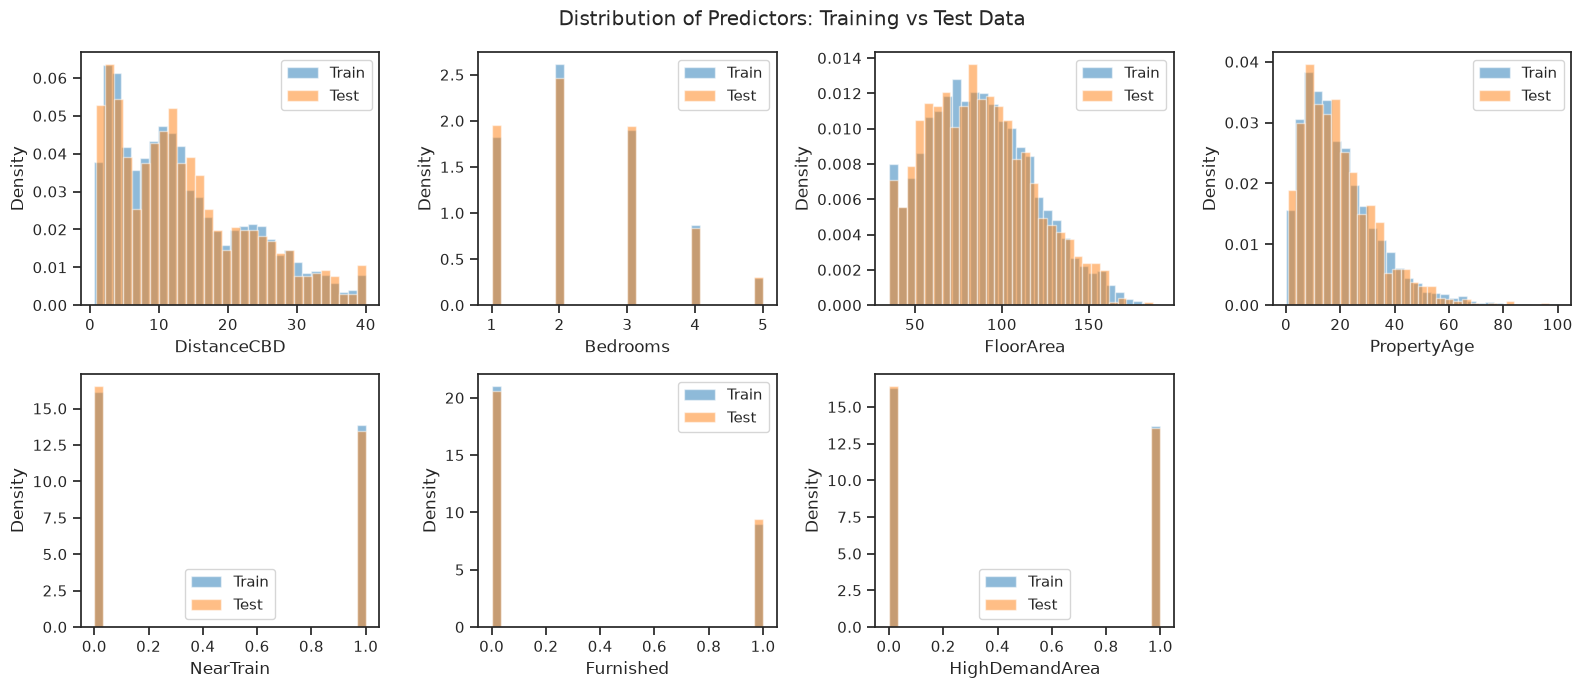

In [7]:
fig, ax = plt.subplots(2, 4, figsize=(16, 7))
ax = ax.flatten()

for i, var in enumerate(predictors):
    ax[i].hist(train[var], bins=30, density=True, alpha = 0.5, label = "Train")
    ax[i].hist(test[var], bins=30, density=True, alpha = 0.5, label = "Test")
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Density")
    ax[i].legend()

ax[7].axis('off') # only 7 predictors, so the last panel is empty
fig.suptitle("Distribution of Predictors: Training vs Test Data")
plt.tight_layout()
plt.show()

### 2.5 Distribution of the response

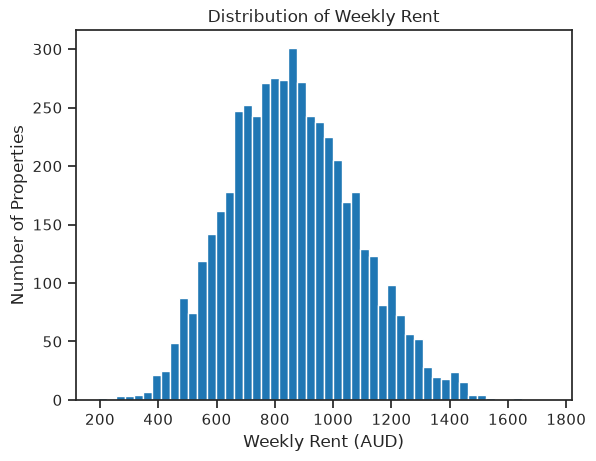

Mean: 860.6811, median: 849.0900, std: 215.4138, skewness: 0.2660


In [8]:
fig = plt.figure()

plt.hist(train[response], bins=50)
plt.xlabel("Weekly Rent (AUD)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Weekly Rent")

plt.show()

print('Mean: {0:.4f}, median: {1:.4f}, std: {2:.4f}, skewness: {3:.4f}'.format(
    train[response].mean(), train[response].median(), train[response].std(), train[response].skew()))

### 2.6 Weekly rent vs continuous predictors

For each continuous predictor we plot the data together with two fitted curves: a straight line
(simple linear regression) and a quadratic curve (polynomial regression of degree 2).
If the quadratic curve departs clearly from the straight line, the relationship is non-linear.

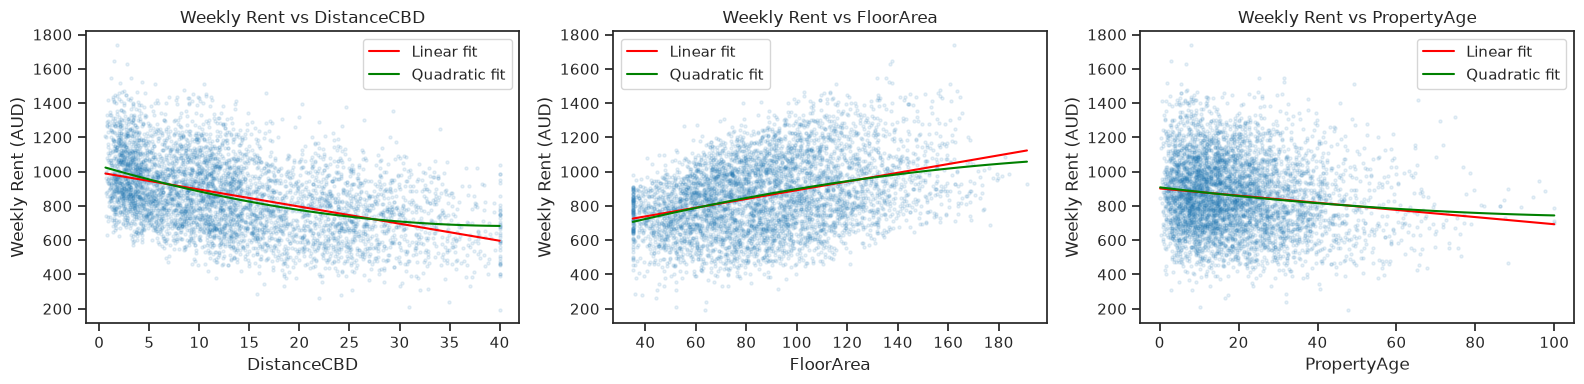

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# One row of three panels, one panel per continuous predictor
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

for i, var in enumerate(continuous):
    x = train[[var]].values                    # predictor as a 2-D array (sklearn needs 2-D input)
    y = train[response]                        # weekly rent
    x_points = np.linspace(x.min(), x.max(), 100).reshape(-1, 1) # evenly spaced values to draw the curves

    # Straight line: rent = b0 + b1*x
    lin_reg = LinearRegression()
    lin_reg.fit(x, y)

    # Quadratic curve: rent = b0 + b1*x + b2*x^2
    poly_transformer = PolynomialFeatures(2)       # will create columns [1, x, x^2]
    poly_x = poly_transformer.fit_transform(x)     # the new 3-column data
    poly_reg = LinearRegression()
    poly_reg.fit(poly_x, y)

    ax[i].scatter(x, y, alpha = 0.1, s = 5)
    ax[i].plot(x_points, lin_reg.predict(x_points), color = "red", label = "Linear fit")
    ax[i].plot(x_points, poly_reg.predict(poly_transformer.transform(x_points)), color = "green", label = "Quadratic fit")
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Weekly Rent (AUD)")
    ax[i].set_title("Weekly Rent vs " + var)
    ax[i].legend()

plt.tight_layout()
plt.show()

### 2.7 Weekly rent by `Bedrooms` and by the binary predictors

Box plots compare the distribution of weekly rent across the groups of each discrete predictor.
The table below the plot gives the group means.

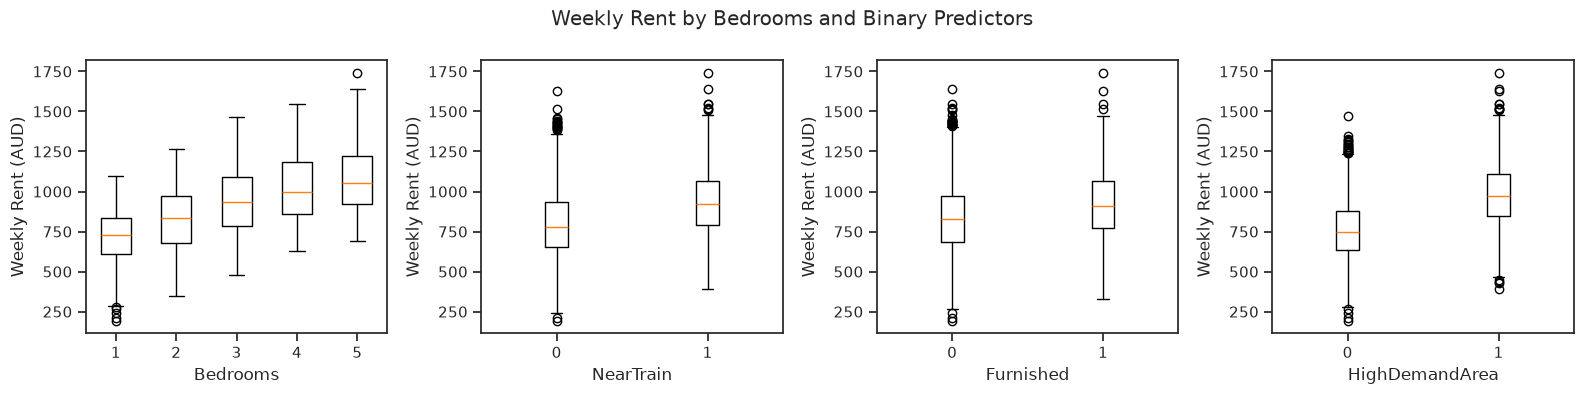

In [10]:
# NOTE: not from tutorial — reason: box plots are requested for this EDA; the tutorials compare groups with overlaid histograms (W1)
group_vars = ['Bedrooms'] + binary     # join two lists: ['Bedrooms', 'NearTrain', 'Furnished', 'HighDemandArea']

# One row of four panels, one per grouping variable
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

for i, var in enumerate(group_vars):
    levels = sorted(train[var].unique())     # the distinct values of this variable, e.g. [0, 1]

    # Collect the rents of each group into a list
    groups = []                              # start with an empty list
    for level in levels:
        rent_in_group = train.loc[train[var] == level, response]   # rents of properties in this group
        groups.append(rent_in_group)                               # add them to the list

    ax[i].boxplot(groups)                    # one box per group
    ax[i].set_xticklabels(levels)            # label each box with its group value (default would be 1, 2, ...)
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Weekly Rent (AUD)")

fig.suptitle("Weekly Rent by Bedrooms and Binary Predictors")   # title for the whole figure
plt.tight_layout()                           # adjust spacing so labels do not overlap
plt.show()

In [11]:
# For each grouping variable, show how many properties are in each group and their mean rent
for var in group_vars:
    # groupby(var): split the data into groups by the value of var (e.g. NearTrain = 0 and 1)
    # [response]: look at weekly rent only
    # agg(['count', 'mean']): for each group, count the properties and compute the mean rent
    # '\n': print a blank line between the tables
    print(train.groupby(var)[response].agg(['count', 'mean']).round(4), '\n')

          count       mean
Bedrooms                  
1          1213   717.9369
2          1741   823.7616
3          1264   938.8978
4           583  1020.8464
5           199  1087.7315 

           count      mean
NearTrain                 
0           2690  797.2066
1           2310  934.5973 

           count      mean
Furnished                 
0           3501  835.9160
1           1499  918.5214 

                count      mean
HighDemandArea                 
0                2719  759.2359
1                2281  981.6058 



**Summary.** Rent rises with the number of bedrooms (718 to 1088 AUD), but by less for each extra bedroom.
High-demand areas (+222 AUD), train access (+137) and furnishing (+83) are all linked to higher rent.
These are raw differences that do not control for the other predictors.

### 2.8 Correlations

The correlation matrix shows the linear association between each pair of variables.
It is used both to rank predictors by their linear association with rent and to detect multicollinearity among predictors.
Correlations only capture linear relationships, so they are read together with the plots above.

In [12]:
correlations = train.corr()
correlations.round(4)

,WeeklyRent,DistanceCBD,Bedrooms,FloorArea,PropertyAge,NearTrain,Furnished,HighDemandArea
WeeklyRent,1.0000,-0.4421,0.5062,0.3567,-0.1375,0.3180,0.1757,0.5142
DistanceCBD,-0.4421,1.0000,0.3319,0.5286,0.0163,-0.1780,-0.1300,-0.3727
Bedrooms,0.5062,0.3319,1.0000,0.8821,-0.0009,-0.0589,-0.1297,-0.1276
FloorArea,0.3567,0.5286,0.8821,1.0000,-0.0079,-0.0882,-0.1339,-0.1947
PropertyAge,-0.1375,0.0163,-0.0009,-0.0079,1.0000,0.0186,-0.0598,-0.0104
NearTrain,0.3180,-0.1780,-0.0589,-0.0882,0.0186,1.0000,0.0039,0.2385
Furnished,0.1757,-0.1300,-0.1297,-0.1339,-0.0598,0.0039,1.0000,0.0273
HighDemandArea,0.5142,-0.3727,-0.1276,-0.1947,-0.0104,0.2385,0.0273,1.0000


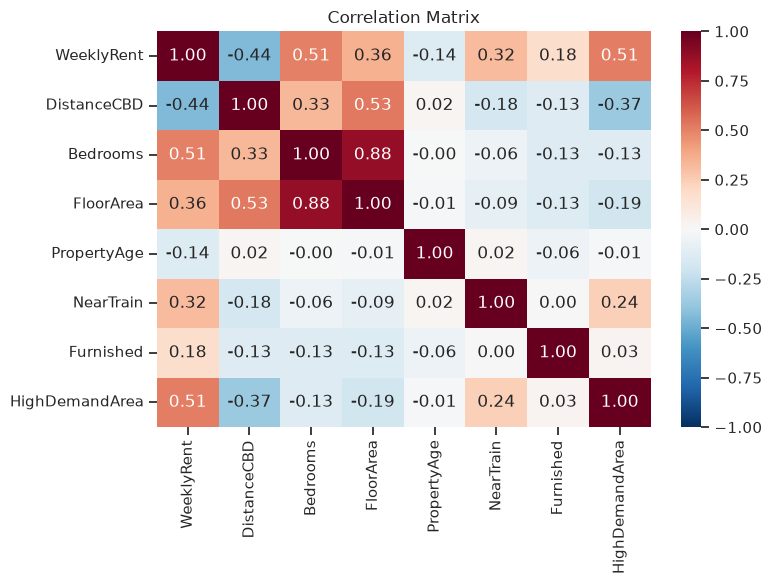

In [13]:
# NOTE: not from tutorial — reason: a heatmap displays the correlation table above more clearly (seaborn is used in W2)
fig = plt.figure(figsize=(8, 6))

sns.heatmap(correlations, annot = True, fmt = ".2f", cmap = "RdBu_r", vmin = -1, vmax = 1)
plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

We now focus on the first column of the table: the correlation of each predictor with weekly rent,
sorted from the strongest positive to the strongest negative association (as in Tutorial 5).

In [14]:
# Correlation of each predictor with rent (the WeeklyRent column), without rent itself
rent_corr = correlations[response].drop(response)
# Sort from the largest to the smallest value
rent_corr = rent_corr.sort_values(ascending = False)
rent_corr.round(4)

HighDemandArea    0.5142
Bedrooms          0.5062
FloorArea         0.3567
NearTrain         0.3180
Furnished         0.1757
PropertyAge      -0.1375
DistanceCBD      -0.4421
Name: WeeklyRent, dtype: float64

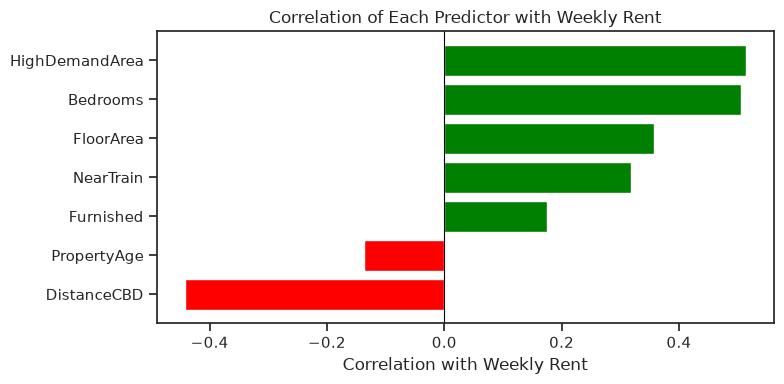

In [15]:
# NOTE: not from tutorial — reason: a bar chart shows the ranking of the correlations above more clearly
fig = plt.figure(figsize=(8, 4))

# One horizontal bar per predictor; green = positive, red = negative correlation
colors = ["green" if value > 0 else "red" for value in rent_corr]
plt.barh(rent_corr.index, rent_corr.values, color = colors)
plt.axvline(0, color = "black", linewidth = 0.8)   # vertical line at zero
plt.gca().invert_yaxis()                            # put the strongest positive correlation at the top
plt.xlabel("Correlation with Weekly Rent")
plt.title("Correlation of Each Predictor with Weekly Rent")
plt.tight_layout()

plt.show()

**Summary.** `HighDemandArea` and `Bedrooms` have the strongest linear association with rent (0.51),
followed by `DistanceCBD` (-0.44); `PropertyAge` has the weakest (-0.14).
`Bedrooms` and `FloorArea` are highly correlated (0.88), so their individual coefficients may be unstable;
the other predictors are only weakly to moderately correlated with each other.

### 2.9 Interaction exploration

An **interaction** means that the effect of one predictor on rent depends on the value of another predictor
(Lecture 2). For example, in the model rent = b0 + b1 x Bedrooms + b2 x HighDemandArea + b3 x Bedrooms x HighDemandArea,
the effect of one extra bedroom is b1 in normal areas but b1 + b3 in high-demand areas.
Lecture 2 notes that finding such non-linear effects "requires domain-knowledge, or trial and error".
Here we use plots of candidate pairs suggested by domain knowledge; a systematic check of all pairs is part of the modelling section.

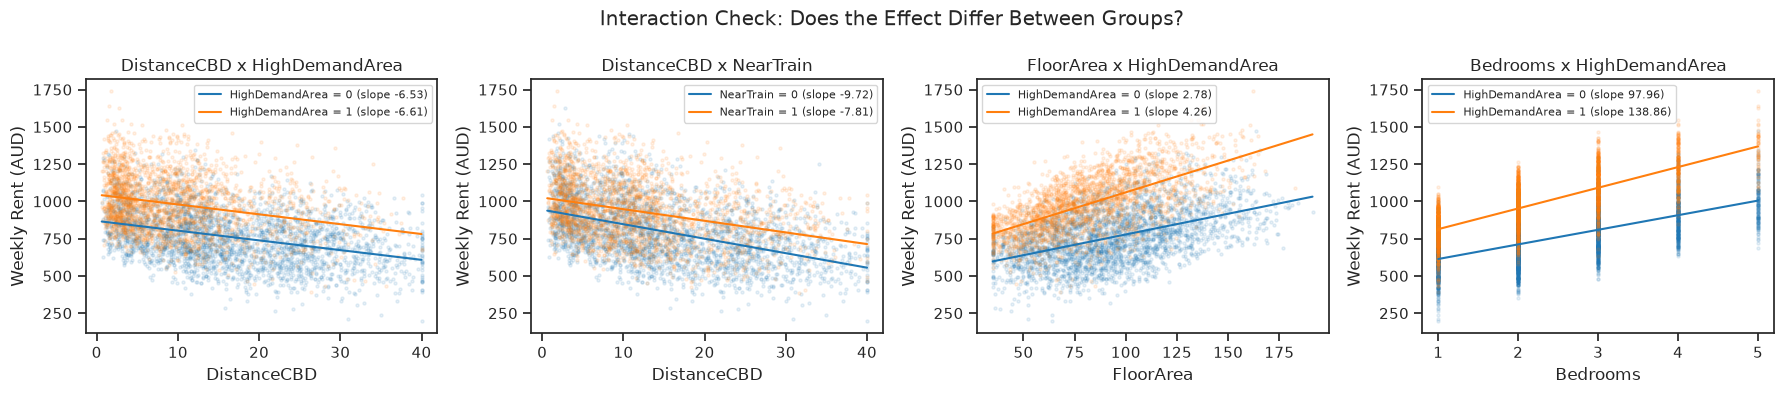

In [16]:
# Pairs to check: (predictor on the x-axis, binary variable used to split the data)
pairs = [('DistanceCBD', 'HighDemandArea'), ('DistanceCBD', 'NearTrain'),
         ('FloorArea', 'HighDemandArea'), ('Bedrooms', 'HighDemandArea')]

fig, ax = plt.subplots(1, 4, figsize=(18, 4))     # one row of four panels

for i, (var, group) in enumerate(pairs):
    # Two groups: level 0 in blue, level 1 in orange (zip pairs each level with a colour)
    for level, color in zip([0, 1], ["#1F77B4", "#FF7F0E"]):
        subset = train[train[group] == level]                      # properties in this group only
        # Simple OLS within the group: rent = b0 + b1 * var
        x_with_intercept = sm.add_constant(subset[[var]], prepend=True)
        est = sm.OLS(subset[response], x_with_intercept).fit()
        x_points = np.linspace(train[var].min(), train[var].max(), 100)   # points to draw the line

        ax[i].scatter(subset[var], subset[response], alpha = 0.1, s = 5, color = color)
        # Fitted line b0 + b1 * x; the legend shows the slope b1 of this group
        ax[i].plot(x_points, est.params.iloc[0] + est.params.iloc[1] * x_points, color = color,
                   label = "{} = {} (slope {:.2f})".format(group, level, est.params.iloc[1]))
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Weekly Rent (AUD)")
    ax[i].set_title(var + " x " + group)           # which pair this panel checks
    ax[i].legend(fontsize = 8)                     # small legend so it does not cover the points

# Different slopes (non-parallel lines) suggest an interaction
fig.suptitle("Interaction Check: Does the Effect Differ Between Groups?")
plt.tight_layout()
plt.show()

Non-parallel lines suggest an interaction: the slope of `Bedrooms` is 98 in normal areas but 139 in high-demand areas,
and the slope of `FloorArea` is 2.78 vs 4.26, so an extra bedroom or square metre is worth more in high-demand areas.
The two lines for `DistanceCBD` by `HighDemandArea` are almost parallel (-6.53 vs -6.61), so there is little sign of
an interaction there. These slopes do not hold the other predictors fixed (for example, high-demand areas are also
closer to the CBD), so which interaction terms to include is decided formally in the modelling section.

### 2.10 Residuals of a baseline OLS model

We fit OLS with all seven predictors (linear terms only) and plot its residuals.
Systematic patterns in the residuals show what the linear model is missing.

In [17]:
x_with_intercept = sm.add_constant(train[predictors], prepend=True)
ols = sm.OLS(train[response], x_with_intercept)
est = ols.fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:             WeeklyRent   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     9345.
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:49:42   Log-Likelihood:                -27341.
No. Observations:                5000   AIC:                         5.470e+04
Df Residuals:                    4992   BIC:                         5.475e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            481.9479      3.335    144.

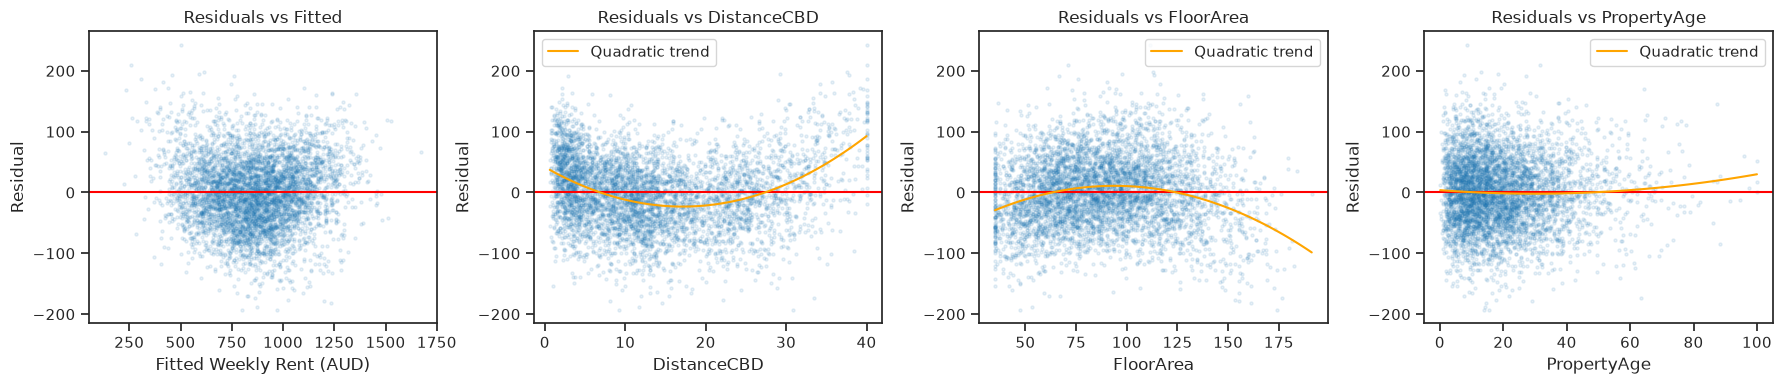

In [18]:
residuals = est.resid
fitted = est.fittedvalues

fig, ax = plt.subplots(1, 4, figsize=(18, 4))

ax[0].scatter(fitted, residuals, alpha = 0.1, s = 5)
ax[0].axhline(0, color = "red")
ax[0].set_xlabel("Fitted Weekly Rent (AUD)")
ax[0].set_ylabel("Residual")
ax[0].set_title("Residuals vs Fitted")

for i, var in enumerate(continuous):
    x = train[[var]].values
    x_points = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    # Quadratic trend of the residuals, to make any curvature easy to see
    poly_transformer = PolynomialFeatures(2)       # will create columns [1, x, x^2]
    poly_x = poly_transformer.fit_transform(x)
    poly_reg = LinearRegression()
    poly_reg.fit(poly_x, residuals)

    ax[i + 1].scatter(x, residuals, alpha = 0.1, s = 5)
    ax[i + 1].axhline(0, color = "red")
    ax[i + 1].plot(x_points, poly_reg.predict(poly_transformer.transform(x_points)), color = "orange", label = "Quadratic trend")
    ax[i + 1].set_xlabel(var)
    ax[i + 1].set_ylabel("Residual")
    ax[i + 1].set_title("Residuals vs " + var)
    ax[i + 1].legend()

plt.tight_layout()
plt.show()

**Outlier check.** An outlier in regression is an observation that the model predicts very badly.
To judge what counts as "very badly", each residual is divided by the estimated standard deviation of the errors
(the *standardised residual*). If the errors are roughly normal, about 99.73% of standardised residuals should lie
between -3 and 3, so values beyond ±3 are unusual. We count them and compare the count with the number expected by chance.

In [19]:
from scipy import stats

# Estimated standard deviation of the errors (square root of the residual mean squared error)
sigma_hat = np.sqrt(est.mse_resid)
# Standardised residual = residual / sigma_hat
std_resid = residuals / sigma_hat

# Flag observations more than 3 standard deviations away from their fitted value
outliers = np.abs(std_resid) > 3
# Number expected by chance if the errors are normal: n x P(|Z| > 3)
expected = len(train) * 2 * (1 - stats.norm.cdf(3))

print('Observations with |standardised residual| > 3: {}'.format(outliers.sum()))
print('Expected by chance under normal errors:        {0:.4f}'.format(expected))
print('Largest |standardised residual|:              {0:.4f}'.format(np.abs(std_resid).max()))

Observations with |standardised residual| > 3: 17
Expected by chance under normal errors:        13.4990
Largest |standardised residual|:              4.2356


In [20]:
# Show the flagged observations, sorted by their standardised residual
outlier_rows = train[outliers].copy()
outlier_rows['std_resid'] = std_resid[outliers]
outlier_rows.sort_values('std_resid').round(4)

,WeeklyRent,DistanceCBD,Bedrooms,FloorArea,PropertyAge,NearTrain,Furnished,HighDemandArea,std_resid
56,779.24,30.82,5,174.3,15.6,0,0,0,-3.3569
2503,606.96,9.19,1,47.5,13.9,1,0,1,-3.3540
3018,683.11,11.67,1,53.1,14.2,1,1,1,-3.2787
2046,1054.19,14.51,5,161.1,14.7,1,0,0,-3.1635
908,1023.68,8.06,5,155.4,29.2,0,0,0,-3.1113
48,847.13,22.18,5,153.3,17.6,0,0,0,-3.0711
1300,689.50,33.42,5,176.7,63.3,0,0,0,-3.0137
4635,1273.12,2.16,3,60.6,19.4,0,1,1,3.0014
3653,926.79,34.22,3,116.5,20.1,1,1,0,3.1136
1332,598.04,35.68,1,90.0,6.5,1,0,0,3.1598


17 observations have a standardised residual beyond ±3, close to the 13.5 expected by chance among 5000 observations,
and the largest is 4.24, so there are no extreme outliers. The flagged properties also follow a clear pattern:
most positive residuals (rent under-predicted) are far from the CBD (around 30–40 km), and most negative residuals
(rent over-predicted) are large five-bedroom properties. These are the regions where the linear model misses the
curvature found above, rather than data errors, so all observations are kept.

### 2.11 Summary of EDA findings

1. **Data quality.** 5000 training and 1000 test rows, all numeric, no missing values or duplicates.
   The binary predictors are already 0/1 dummies.
2. **Train vs test.** Test covariates have very similar means, spreads and ranges to the training covariates,
   so the model will not need to extrapolate.
3. **Outliers.** The minimum and maximum of every variable are plausible. In the baseline OLS, 17 observations have
   |standardised residual| > 3 (13.5 expected by chance); they are mainly distant or five-bedroom properties that the
   linear model fits poorly, not data errors, so all observations are kept. `DistanceCBD` has a maximum of exactly 40 km
   and `FloorArea` a minimum of exactly 35 m², which may be capped values.
4. **Response.** `WeeklyRent` is roughly symmetric (skewness 0.27), so no transformation of the response is needed.
5. **Non-linearity.** Rent falls with distance but flattens out far from the CBD (U-shaped OLS residuals),
   and rises with floor area at a decreasing rate (inverted-U residuals). `PropertyAge` is close to linear.
6. **Group differences.** High-demand areas (+222 AUD on average), proximity to a train station (+137) and
   furnishing (+83) are all associated with higher rent; rent rises steadily with the number of bedrooms.
7. **Multicollinearity.** `Bedrooms` and `FloorArea` are highly correlated (0.88); the other predictor
   correlations are moderate (at most 0.53 in absolute value).
8. **Interactions.** The effects of `Bedrooms` and `FloorArea` on rent are larger in high-demand areas
   (slopes 139 vs 98 per bedroom, 4.26 vs 2.78 per m²), while the distance effect is similar in both groups.
   Candidate interaction terms are selected formally in the modelling section.
9. **Baseline OLS.** The linear model already explains most of the variation (R² = 0.929), but the residual patterns
   confirm that non-linear and interaction terms are needed.